Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

Load the dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

Data Preprocessing

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(1470, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
drop_cols = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df.drop(columns=drop_cols, inplace=True)

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [10]:
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [11]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [12]:
df.corr

<bound method DataFrame.corr of       Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0      41          1               2       1102           2                 1   
1      49          0               1        279           1                 8   
2      37          1               2       1373           1                 2   
3      33          0               1       1392           1                 3   
4      27          0               2        591           1                 2   
...   ...        ...             ...        ...         ...               ...   
1465   36          0               1        884           1                23   
1466   39          0               2        613           1                 6   
1467   27          0               2        155           1                 4   
1468   49          0               1       1023           2                 2   
1469   34          0               2        628           1                 8

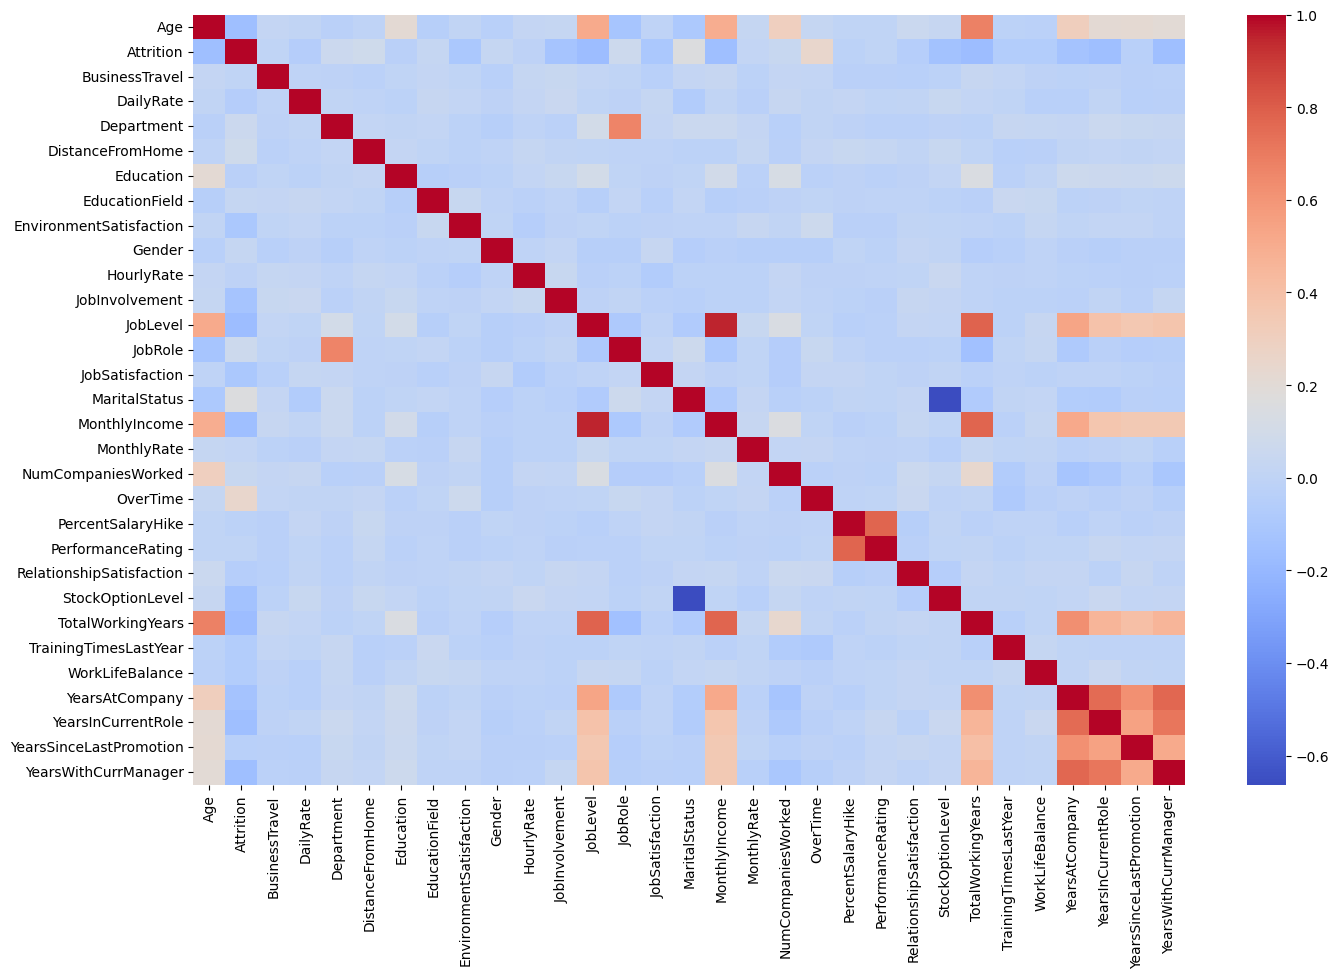

In [13]:
# numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20676\3107204767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition',data=df, palette="Set1")


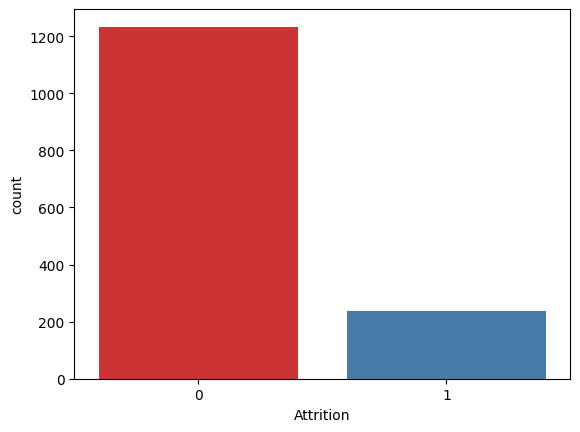

Attrition
0    1233
1     237
Name: count, dtype: int64


In [14]:
plt.Figure(figsize=(6,4))
sns.countplot(x='Attrition',data=df, palette="Set1")
plt.show()
print(df["Attrition"].value_counts())

In [15]:
X= df.drop('Attrition', axis=1)
y= df['Attrition']

In [16]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,2,0,94,...,3,1,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,3,1,61,...,4,4,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,4,1,92,...,3,2,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,4,0,56,...,3,3,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,1,40,...,3,4,1,6,3,3,2,2,2,2


In [17]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

Done data splitting for training and testing

In [18]:
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

In [19]:
def bootstrap_sample(X,y):
    n_samples = X.shape[0]
    indices = np.random.choice(np.arange(n_samples),size=n_samples,replace=True)
    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]

    return X_bootstrap,y_bootstrap,indices

In [20]:
n_bootstraps= 5
bootstrap_info = []

for i in range(n_bootstraps):
    X_bs , y_bs, indices = bootstrap_sample(X_train,y_train)

    unique_count = len(np.unique(indices))
    unique_percentage = unique_count/len(indices)*100
    oob_percentage = 100 - unique_percentage

    bootstrap_info.append({
        "Bootstrao_no" : i+1,
        "Unique_%": unique_percentage,
        "oob_%" : oob_percentage
    })

In [21]:
bootstrap_df = pd.DataFrame(bootstrap_info)
bootstrap_df

,Bootstrao_no,Unique_%,oob_%
0,1,63.350340,36.649660
1,2,64.285714,35.714286
2,3,64.030612,35.969388
3,4,65.051020,34.948980
4,5,62.500000,37.500000


In [22]:
n_trees = 5
trees = []
tree_accuracies = []

for i in range(n_trees):
    X_bs,y_bs,_ = bootstrap_sample(X_train,y_train)

    tree = DecisionTreeClassifier(random_state=i,max_depth=None)

    tree.fit(X_bs,y_bs)

    trees.append(tree)

    y_pred_tree = tree.predict(X_test)
    acc = accuracy_score(y_test,y_pred_tree)
    tree_accuracies.append(acc)

In [23]:
for i , acc in enumerate(tree_accuracies,start=1):
    print(f"Decision Tree{i} Accuracy : {acc:.4f}")

Decision Tree1 Accuracy : 0.7279
Decision Tree2 Accuracy : 0.7619
Decision Tree3 Accuracy : 0.7721
Decision Tree4 Accuracy : 0.7313
Decision Tree5 Accuracy : 0.8129


In [24]:
all_predictions = []

for tree in trees:
    all_predictions.append(tree.predict(X_test))

all_predictions = np.array(all_predictions)

In [25]:
y_pred_bagged = np.round(all_predictions.mean(axis=0)).astype(int)

In [26]:
bagged_accuracy = accuracy_score(y_test, y_pred_bagged)
print(f"Bagged Ensemble Accuracy: {bagged_accuracy:.4f}")

Bagged Ensemble Accuracy: 0.8265


In [27]:
print("Individual Tree Accuracies:")
print(tree_accuracies)

print(f"\nAverage Individual Accuracy: {np.mean(tree_accuracies):.4f}")
print(f"Bagged Model Accuracy: {bagged_accuracy:.4f}")

Individual Tree Accuracies:
[0.7278911564625851, 0.7619047619047619, 0.7721088435374149, 0.7312925170068028, 0.8129251700680272]

Average Individual Accuracy: 0.7612
Bagged Model Accuracy: 0.8265


In [28]:
max_features_list = ["sqrt", "log2", None]  # None = all features

In [29]:
rf_results = {}

for mf in max_features_list:
    rf = RandomForestClassifier(
        n_estimators=5,          # same as bagged trees
        max_features=mf,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    rf_results[str(mf)] = acc

In [30]:
for k, v in rf_results.items():
    print(f"max_features = {k} → Accuracy = {v:.4f}")
print(f"Bagged Trees Accuracy: {bagged_accuracy:.4f}")

max_features = sqrt → Accuracy = 0.8401
max_features = log2 → Accuracy = 0.8299
max_features = None → Accuracy = 0.8197
Bagged Trees Accuracy: 0.8265


In [46]:
n_estimators_list = [10, 25,50,100]
rf_accuracies = []

for n in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=None,
        max_features="sqrt",
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    rf_accuracies.append(acc)
    
    print(f"n_estimators = {n} → Accuracy = {acc:.4f}")

n_estimators = 10 → Accuracy = 0.8435
n_estimators = 25 → Accuracy = 0.8435
n_estimators = 50 → Accuracy = 0.8401
n_estimators = 100 → Accuracy = 0.8435


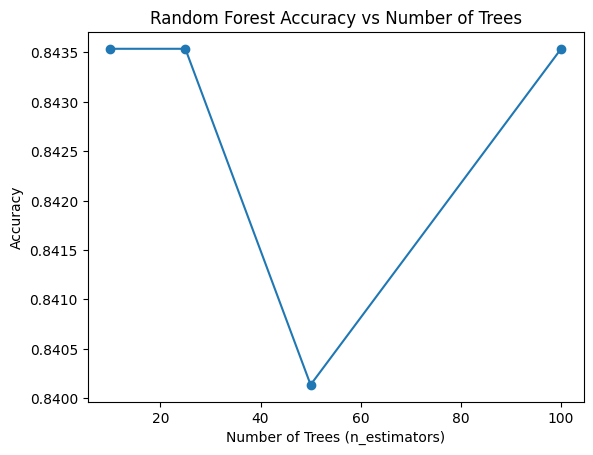

In [33]:
plt.figure()
plt.plot(n_estimators_list, rf_accuracies, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.show()

In [34]:
importances = rf.feature_importances_
feature_names = X_train.columns

In [35]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

In [36]:
top_10_features = feature_importance_df.head(10)
top_10_features

,Feature,Importance
15,MonthlyIncome,0.073336
0,Age,0.068557
23,TotalWorkingYears,0.065480
9,HourlyRate,0.054217
2,DailyRate,0.052526
16,MonthlyRate,0.051631
4,DistanceFromHome,0.049930
26,YearsAtCompany,0.043107
18,OverTime,0.038350
17,NumCompaniesWorked,0.035546


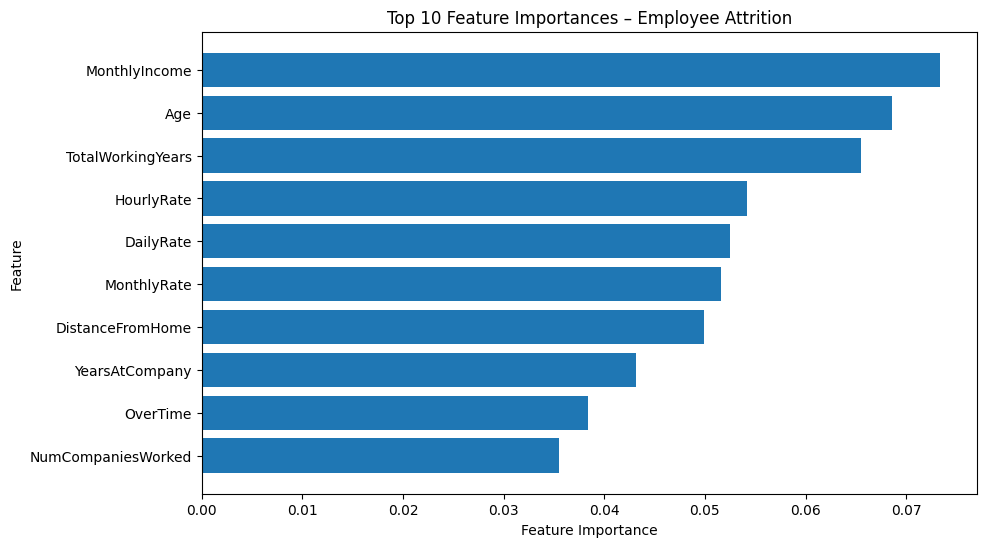

In [37]:
plt.figure(figsize=(10,6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances – Employee Attrition")
plt.gca().invert_yaxis()
plt.show()

In [50]:
new_samples = [[
34, 1, 950, 1, 8, 3, 2, 3, 1, 65,
3, 2, 3, 4, 1, 5200, 18000, 2, 1, 14,
3, 3, 1, 10, 3, 3, 6, 4, 2, 5
]]

predictions = rf.predict(new_samples)
print("Predictions for new samples:")
print(predictions)


Predictions for new samples:
[0]


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
